# Lab 05: Exploratory Data Analysis

**Week:** 3  
**Type:** Independent  
**Corresponding working sessions:** `working-sessions/eda/`  
**Estimated time:** 60–75 minutes  
**Dataset:** Heart Disease (Cleveland)

---

### Learning Objectives

By the end of this lab you will be able to:

- **Inspect** a new dataset and characterize its shape, types, and completeness
- **Detect and handle** missing values and duplicate records
- **Identify** outliers using the IQR method
- **Produce and interpret** univariate and bivariate visualizations using matplotlib and seaborn
- **Apply** a log transformation to a right-skewed feature and explain why it helps

---

### Context

The Heart Disease dataset comes from a study at the Cleveland Clinic Foundation.
It contains records for 303 patients — including age, sex, chest pain type, cholesterol,
resting blood pressure, and maximum heart rate — along with a binary outcome indicating
whether heart disease was detected.

Your task: explore this dataset from scratch, exactly as you would at the start of a
real data science project.

Run the cells in order. Each section builds on the one before it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tkh_utils import (
    PALETTE, FONT, base_layout,
    check_answer, make_answer_key, make_grading_summary,
    load_heart_disease
)

In [2]:
_ak = make_answer_key({
    'q1': 'B',
    'q2': 'C',
    'q3': 'C',
    'q4': 'C',
})

# Load the dataset
X, y = load_heart_disease()
df = X.copy()
df['target'] = y  # 0 = no heart disease detected, 1 = heart disease detected

print(f"Dataset loaded: {df.shape[0]} patients, {df.shape[1]} columns")
df.head()

Dataset loaded: 303 patients, 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1


---

**Column reference:**

| Column | Description |
|--------|-------------|
| `age` | Age in years |
| `sex` | Sex (1 = male, 0 = female) |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of the peak exercise ST segment (0–2) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) |
| `thal` | Thalassemia type (0–3) |
| `target` | Outcome: 1 = heart disease detected, 0 = not detected |

For more on this dataset visit: [here](https://archive.ics.uci.edu/dataset/45/heart+disease)

---

## Section A — Conceptual Questions

For each question below, replace `"___"` with your answer (`"A"`, `"B"`, `"C"`, or `"D"`).
Run the cell after filling in your answer — you will get immediate feedback.

In [121]:
# Question 1
# Which of the following best describes the primary goal of exploratory data analysis (EDA)?
#
#   A) To test a hypothesis and confirm whether it is true or false
#   B) To understand the structure, quality, and patterns in a dataset before modeling
#   C) To train a machine learning model with the best possible accuracy
#   D) To remove all outliers and missing values before analysis

q1_answer = "B"  # Replace with A, B, C, or D

assert q1_answer != "___", "Don't forget to fill in your answer."
assert check_answer(q1_answer, _ak['q1']), \
    "Not quite — EDA is about understanding, not cleaning or modeling. " \
    "Revisit working-sessions/eda/01_what_is_eda.ipynb"
print("✓ Question 1 correct!")

✓ Question 1 correct!


In [122]:
# Question 2
# You call df.info() on a new DataFrame. Which of the following will it tell you?
#
#   A) The mean, median, and standard deviation of each numeric column
#   B) The number of unique values in each categorical column
#   C) The number of non-null values and the data type of each column
#   D) The correlation between every pair of numeric columns

q2_answer = "C"  # Replace with A, B, C, or D

assert q2_answer != "___", "Don't forget to fill in your answer."
assert check_answer(q2_answer, _ak['q2']), \
    "Not quite — compare what .info() shows versus .describe(). " \
    "Revisit working-sessions/eda/02_loading_and_inspecting_data.ipynb"
print("✓ Question 2 correct!")

✓ Question 2 correct!


In [123]:
# Question 3
# A column in your dataset has 78% of its values missing, and the missing values
# appear to be unrelated to any other variable in the dataset.
# Which strategy is most appropriate?
#
#   A) Fill missing values with the column mean
#   B) Fill missing values with 0
#   C) Drop the column entirely
#   D) Leave the values as NaN and proceed without making any changes

q3_answer = "C"  # Replace with A, B, C, or D

assert q3_answer != "___", "Don't forget to fill in your answer."
assert check_answer(q3_answer, _ak['q3']), \
    "Not quite — when 78% of a column is missing, imputation introduces more noise than signal. " \
    "Revisit working-sessions/eda/04_missing_data.ipynb"
print("✓ Question 3 correct!")

✓ Question 3 correct!


In [124]:
# Question 4
# When using the IQR method to flag outliers, a value is considered an outlier if it falls:
#
#   A) More than 2 standard deviations from the mean
#   B) More than 3 standard deviations from the mean
#   C) Below Q1 - 1.5 * IQR  or  above Q3 + 1.5 * IQR
#   D) Below Q1 - 2.0 * IQR  or  above Q3 + 2.0 * IQR

q4_answer = "C"  # Replace with A, B, C, or D

assert q4_answer != "___", "Don't forget to fill in your answer."
assert check_answer(q4_answer, _ak['q4']), \
    "Not quite — the IQR method uses quartiles, not the mean or standard deviation. " \
    "Revisit working-sessions/eda/06_outlier_detection.ipynb"
print("✓ Question 4 correct!")

✓ Question 4 correct!


---

## Section B — Code Exercises

Fill in each `___` to complete the code. There may be more than one blank per exercise.
Run the cell to check your work.

### Exercise B1 — Inspecting a new dataset

Use the `df` DataFrame loaded above to answer the following:

- Unpack `df.shape` into `n_rows` and `n_cols`
- Count the total number of missing values across **all** columns (store as `missing_count`)
- Compute the median patient age (store as `median_age`)
- Count how many columns are stored as `float64` (store as `n_float_cols`)

*Reference: `working-sessions/eda/02_loading_and_inspecting_data.ipynb` and `03_data_types_and_casting.ipynb`*

In [125]:
n_rows, n_cols = df.shape           # df.shape

missing_count = df.isnull().sum().sum()         # total missing values across all columns

median_age = df['age'].median()               # median of the 'age' column

n_float_cols = (df.dtypes == 'float64').sum()           # number of columns with dtype float64

# --- checks ---
assert isinstance(n_rows, int), \
    "n_rows should be an int — unpack df.shape into (n_rows, n_cols)"
assert n_rows == 303 and n_cols == 14, \
    f"Expected shape (303, 14) — got ({n_rows}, {n_cols})"
assert missing_count == 0, \
    "missing_count should be 0 — this dataset has no missing values. " \
    "Use df.isnull().sum().sum()"
assert abs(median_age - 55.0) < 0.5, \
    "median_age should be 55.0 — check df['age'].median()"
assert n_float_cols == 13, \
    "13 of the 14 columns are float64 — use (df.dtypes == 'float64').sum()"
print(f"✓ Shape: {n_rows} rows, {n_cols} columns")
print(f"  Missing values: {missing_count}")
print(f"  Median age: {median_age:.1f} years")
print(f"  Float64 columns: {n_float_cols} of {n_cols}")

✓ Shape: 303 rows, 14 columns
  Missing values: 0
  Median age: 55.0 years
  Float64 columns: 13 of 14


### Exercise B2 — Handling missing values

Many real datasets arrive with missing data. The cell below creates a copy of `df`
with 25 values deliberately removed from the `thal` column so you can practice the
full missing-value workflow.

Your tasks:
- Compute the percentage of values missing in each column (store as `missing_pct`)
- Fill the missing `thal` values with the column median (overwrite `df_missing['thal']`)
- Verify that no missing values remain in `thal` (store as `remaining_missing`)

*Reference: `working-sessions/eda/04_missing_data.ipynb`*

In [126]:
# Pre-filled — run this cell to create a version of df with simulated missing values
np.random.seed(42)
missing_idx = np.random.choice(df.index, size=25, replace=False)
df_missing = df.copy()
df_missing.loc[missing_idx, 'thal'] = np.nan
print(f"df_missing: {df_missing['thal'].isna().sum()} missing values injected into 'thal'")

df_missing: 25 missing values injected into 'thal'


In [127]:
missing_pct = (df_missing.isnull().sum() / len(df_missing)) * 100         # percentage of values missing per column
                               

df_missing['thal'] = df_missing['thal'].fillna(df_missing['thal'].median())       # fill missing thal values with the column median

remaining_missing = df_missing['thal'].isna().sum()        # number of missing values in 'thal' after filling

# --- checks ---
assert isinstance(missing_pct, pd.Series), \
    "missing_pct should be a pandas Series — use df_missing.isnull().sum() / len(df_missing) * 100"
assert abs(missing_pct['thal'] - 25 / 303 * 100) < 0.5, \
    "missing_pct['thal'] should be near 8.25% — check your formula"
assert remaining_missing == 0, \
    "remaining_missing should be 0 — use fillna(df_missing['thal'].median())"
print(f"✓ Missing values handled")
print(f"  Before: {missing_pct['thal']:.2f}% missing in 'thal'")
print(f"  After:  {remaining_missing} remaining")

✓ Missing values handled
  Before: 8.25% missing in 'thal'
  After:  0 remaining


### Exercise B3 — GroupBy analysis

Grouped analysis lets you compare a numeric column across different outcome groups.

Your tasks:
- Compute the mean cholesterol for each target group (0 = no disease, 1 = disease).
  Store as `avg_chol_by_target`
- Compute the difference: mean cholesterol in the disease group minus the no-disease group.
  Store as `chol_difference`

*Reference: `working-sessions/eda/07b_groupby_and_pivot_tables.ipynb`*

In [128]:
avg_chol_by_target = df.groupby('target')['chol'].agg('mean')
print(avg_chol_by_target.iloc[1]-avg_chol_by_target.iloc[0])
avg_chol_by_target

-8.856653491436106


target
0    251.086957
1    242.230303
Name: chol, dtype: float64

In [129]:
avg_chol_by_target = df.groupby('target')['chol'].agg('mean')       

chol_difference =   avg_chol_by_target.iloc[1]-avg_chol_by_target.iloc[0]   

# --- checks ---
assert isinstance(avg_chol_by_target, pd.Series), \
    "avg_chol_by_target should be a Series — use df.groupby('target')['chol'].mean()"
assert len(avg_chol_by_target) == 2, \
    "The result should have 2 groups — target = 0 and target = 1"
assert abs(chol_difference) < 20, \
    "The difference should be under 20 mg/dl — check avg_chol_by_target[1] - avg_chol_by_target[0]"
print(f"✓ GroupBy complete")
print(f"  Avg cholesterol — no disease (0): {avg_chol_by_target[0]:.1f} mg/dl")
print(f"  Avg cholesterol — disease (1):    {avg_chol_by_target[1]:.1f} mg/dl")
print(f"  Difference (disease - no disease): {chol_difference:.1f} mg/dl")
print()
print("Notice: the difference is small — and may point in a direction you didn't expect.")
print("Section D asks you to interpret this finding.")

✓ GroupBy complete
  Avg cholesterol — no disease (0): 251.1 mg/dl
  Avg cholesterol — disease (1):    242.2 mg/dl
  Difference (disease - no disease): -8.9 mg/dl

Notice: the difference is small — and may point in a direction you didn't expect.
Section D asks you to interpret this finding.


---

## Section C — Applied EDA

Work through each task below in order. Visualizations are graded visually — focus on
clear labels and correct axis mapping.

### C1 — Duplicate records

Check whether `df` contains any exact duplicate rows. Store the count as `n_duplicates`.

*Reference: `working-sessions/eda/05_handling_duplicates.ipynb`*

In [130]:
print(df.duplicated().sum())

1


In [131]:
n_duplicates = df.duplicated().sum()            # number of duplicate rows in df

assert isinstance(int(n_duplicates), int), \
    "n_duplicates should be a numeric count — use df.duplicated().sum()"
print(f"✓ Duplicate rows found: {n_duplicates}")
if n_duplicates > 0:
    print(f"  Consider dropping duplicates before modeling: df.drop_duplicates()")
else:
    print("  No duplicates — dataset is clean on this dimension")

✓ Duplicate rows found: 1
  Consider dropping duplicates before modeling: df.drop_duplicates()


### C2 — Outlier detection using the IQR method

Use the IQR method to flag outliers in the `chol` (serum cholesterol) column.

1. Compute `Q1`, `Q3`, and `IQR` for `chol`
2. Calculate `lower_bound` and `upper_bound`
3. Create a DataFrame of the flagged rows and count them as `n_outliers`

*Reference: `working-sessions/eda/06_outlier_detection.ipynb`*

In [135]:
Q1 = df['chol'].quantile(0.25)
Q3 = df['chol'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

outliers = df[(df['chol'] < lower_bound)|(df['chol']<upper_bound)]
n_outliers = len(outliers)

# --- checks ---
assert lower_bound > 0, \
    "lower_bound should be positive — check Q1 - 1.5 * IQR"
assert upper_bound > lower_bound, \
    "upper_bound should be greater than lower_bound"
print(f"✓ IQR outlier detection complete")
print(f"  Q1 = {Q1:.1f},  Q3 = {Q3:.1f},  IQR = {IQR:.1f}")
print(f"  Lower bound: {lower_bound:.1f}  |  Upper bound: {upper_bound:.1f}")
print(f"  Outliers flagged: {n_outliers} of {len(df)} patients ({n_outliers / len(df) * 100:.1f}%)")
print()
print(outliers[['age', 'sex', 'chol', 'target']].to_string())

✓ IQR outlier detection complete
  Q1 = 211.0,  Q3 = 274.5,  IQR = 63.5
  Lower bound: 115.8  |  Upper bound: 369.8
  Outliers flagged: 298 of 303 patients (98.3%)

      age  sex   chol  target
0    63.0  1.0  233.0       1
1    37.0  1.0  250.0       1
2    41.0  0.0  204.0       1
3    56.0  1.0  236.0       1
4    57.0  0.0  354.0       1
5    57.0  1.0  192.0       1
6    56.0  0.0  294.0       1
7    44.0  1.0  263.0       1
8    52.0  1.0  199.0       1
9    57.0  1.0  168.0       1
10   54.0  1.0  239.0       1
11   48.0  0.0  275.0       1
12   49.0  1.0  266.0       1
13   64.0  1.0  211.0       1
14   58.0  0.0  283.0       1
15   50.0  0.0  219.0       1
16   58.0  0.0  340.0       1
17   66.0  0.0  226.0       1
18   43.0  1.0  247.0       1
19   69.0  0.0  239.0       1
20   59.0  1.0  234.0       1
21   44.0  1.0  233.0       1
22   42.0  1.0  226.0       1
23   61.0  1.0  243.0       1
24   40.0  1.0  199.0       1
25   71.0  0.0  302.0       1
26   59.0  1.0  212.0    

### C3 — Univariate visualization

Create a histogram of the `chol` column using seaborn. Label both axes and add a title.

*Reference: `working-sessions/eda/08_univariate_analysis.ipynb`*

More on histograms [here](https://seaborn.pydata.org/generated/seaborn.histplot.html)

(array([ 12.,  73., 106.,  69.,  35.,   3.,   4.,   0.,   0.,   1.]),
 array([126. , 169.8, 213.6, 257.4, 301.2, 345. , 388.8, 432.6, 476.4,
        520.2, 564. ]),
 <BarContainer object of 10 artists>)

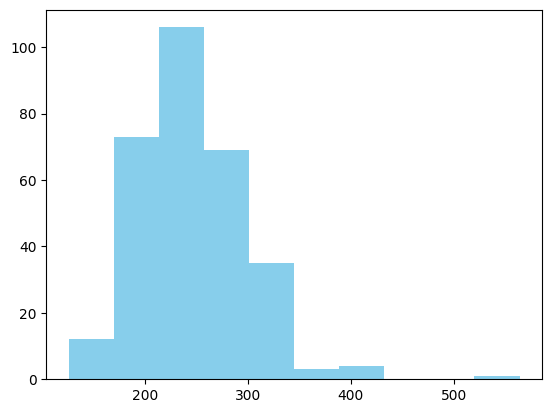

In [140]:
plt.hist(
    data=df, x='chol',color='skyblue',
)

### C4 — Log transformation

The cholesterol distribution is right-skewed. Apply a log transformation using `np.log1p`
and confirm it reduces the absolute skewness. Then produce a side-by-side comparison plot.

*Reference: `working-sessions/eda/11_feature_distributions.ipynb`*

In [ ]:
chol_log = ___ # hint: .skew()
skew_original = ___
skew_log = chol_log.skew()

# --- check ---
assert abs(skew_log) < abs(skew_original), \
    "The log transformation should reduce absolute skewness — check np.log1p(df['chol'])"
print(f"✓ Skewness reduced: {skew_original:.4f}  →  {skew_log:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['chol'], bins=30, ax=axes[0])
axes[0].set_title('Cholesterol — Original')
axes[0].set_xlabel('mg/dl')
axes[0].set_ylabel('Count')

sns.histplot(chol_log, bins=30, ax=axes[1])
axes[1].set_title('Cholesterol — Log Transformed')
axes[1].set_xlabel('log(cholesterol + 1)')
axes[1].set_ylabel('Count')

plt.suptitle(f'Skewness: {skew_original:.2f}  →  {skew_log:.2f}', y=1.02)
plt.tight_layout()
plt.show()

### C5 — Bivariate visualization

Create a scatterplot of `age` (x-axis) versus `thalach` — maximum heart rate achieved —
(y-axis), with points colored by `target`.

Do the two groups separate visually? Note what you observe for Section D.

*Reference: `working-sessions/eda/09_bivariate_analysis.ipynb`*

---

## Section D — Interpretation

These questions are for reflection. Edit the markdown cells below each question
to write your response. There are no wrong answers — we are looking for thoughtful
engagement with the data. Your instructor may review these.

**Question D1**

In Section C2, the cholesterol distribution had a long right tail with a small number of
very high values. In plain language, what does a right-skewed distribution mean? Why might
those extreme cholesterol readings represent genuine patient data rather than measurement errors?

*Your response here...*

**Question D2**

In Exercise B3, you found that the average cholesterol is slightly higher in the
group *without* heart disease than in the group *with* it. This is counterintuitive —
many people assume higher cholesterol is always linked to heart disease.

What does this finding suggest about cholesterol as a standalone predictor of heart disease?
Based on your scatterplot in C5, which feature appears more strongly associated with the
outcome? Support your answer with at least one number from your analysis.

*Your response here...*

**Question D3**

You are about to train a model to predict heart disease using this dataset.
Identify one data quality issue you discovered during your EDA — whether the duplicate row,
the right-skewed cholesterol distribution, or anything else you noticed.

Describe exactly how you would handle it before training, and explain why that step
matters for model performance.

*Your response here...*

---

## Self-Grading Summary

Run the cell below when you are ready to check your Section A score.
Fix any failing checks above and re-run until everything passes.

In [ ]:
make_grading_summary([
    (q1_answer, _ak['q1'], "Q1: Purpose of EDA"),
    (q2_answer, _ak['q2'], "Q2: What df.info() reveals"),
    (q3_answer, _ak['q3'], "Q3: Missing data strategy"),
    (q4_answer, _ak['q4'], "Q4: IQR outlier detection"),
], total=4)
print("Section B & C: check ✓ marks above")
print("Section D: for your own reflection")